# Zadanie 1

W tym ćwiczeniu przygotujemy do pracy środowisko Framsticks oraz interfejs ewolucyjny w Pythonie.

- Pobierz symulator Framsticks i rozpakuj go w jakimś katalogu. Zapamiętaj katalog, do którego trafiła biblioteka frams-objects.dll/.so/.dylib – skrypty pythonowe będą jej używały. `C:\Users\mikol\Desktop\Mikolaj\Studia\Informatyka\sem9\AMEBA\Framsticks53)`
- Pobierz "framspy" (interfejs w Pythonie do Framsticks) czyli ten katalog. Najlepiej go pobrać za pomocą klienta svn (svn checkout) lub git (git svn clone); certyfikat https tylko szyfruje ale nie potwierdza tożsamości strony, więc możesz napotkać ostrzeżenia.
- Sprawdź połączenie kodu pythonowego z symulatorem: upewnij się, że bez błędów działa `python frams-test.py <ścieżka-do-biblioteki-frams-objects>`.
- Zainstaluj framework DEAP pod Pythonem.
- Skopiuj wszystkie pliki *.sim z pobranego repozytorium "framspy" do katalogu data/ w rozpakowanej dystrybucji Framsticks.
- Przeedytuj run-deap-examples.cmd uzupełniając ścieżkę do biblioteki DIR_WITH_FRAMS_LIBRARY, uruchom ten skrypt i upewnij się, że działa ewolucja. Przerobienie tego skryptu pod linuxa jest trywialne.

Zbudujemy teraz pierwszą prostą konstrukcję i zasymulujemy ją.

- Uruchom Framsticks.exe (pod linux i macos możesz użyć wine)
- Kliknij na przycisk "New" w środkowym okienku po lewej, w polu "Genotype" wpisz /\*9\*/LUR
- Początkowy "komentarz" /\*9\*/ oznacza, że używamy reprezentacji genetycznej o symbolu 9; kodowanie o symbolu 9 jest skrótowo nazywane f9 ("f" od "format genetyczny")
- Możesz używać sześciu literek (Left, Right, Down, Up, Back, Forth) rysując wyobrażonym "żółwiem" w 3D dowolną ścieżkę
- Przechodząc kursorem po genotypie albo zaznaczając fragmenty genotypu zobaczysz je podświetlone w konstrukcji 3D
- Klikając na konstrukcję 3D możesz zaznaczać fragmenty (z naciśniętym SHIFT możesz rozszerzać zaznaczenie) i odpowiednie geny zostaną podkreślone
- Zbuduj jakiś ciekawy kształt, a potem kliknij "OK" na dole okienka (genotyp powinien pojawić się na liście genotypów)

Symulacja zbudowanej konstrukcji

- Po lewej u góry widzisz okienko "Groups". Kliknij dwa razy w pozycję "Creatures" i odznacz (wyłącz) checkbox "Death". Dzięki temu, kiedy energia symulowanej konstrukcji spadnie poniżej zera, nie będzie ona automatycznie usunięta z symulacji.
- Zaznacz genotyp na liście genotypów, kliknij przycisk "Simulate" w tym okienku, w małym menu wyboru populacji wybierz "Creatures".
- U góry na toolbarze widzisz trzy czerwone przyciski jak przy odtwarzaniu muzyki. Pierwszy zatrzymuje symulację, drugi robi pojedynczy krok symulacji, trzeci włącza symulację na stałe.
- Włącz symulację. W okienku "Artificial world" wyświetlającym stan symulacji możesz w prawym górnym rogu wybierać tempo symulacji.
Zaznaczenie w dolnym okienku z populacjami symulowanej konstrukcji spowoduje, że kamera się do niej przybliży.
- Podczas gdy symulacja działa, kliknięcie na konstrukcji lewym przyciskiem myszy wraz z naciśnietym CTRL pozwala złapać ją "rączką robota" i ręcznie przesuwać.

Zbuduj sześcian w f9 za pomocą jak najmniejszej liczby literek i wklej jego genotyp w odpowiedzi.

/\*9\*/FDBULFRLDRLBRLU

# Zadanie 2

Jak widać, reprezentacja f9 jest bardzo prosta. Nie pozwala wcale na opisanie sieci neuronowej, a sama konstrukcja składa się z prostopadłych elementów o niezmiennej długości. Zakładając, że w ogólności możliwe są też konstrukcje o różnych długościach i kątach elementów, mapowanie genotyp-fenotyp ("embriogeneza") oznaczone jako f9 jest bardzo restrykcyjne.

Krzyżowanie dwóch genotypów f9 jest jednopunktowe, natomiast mutacja ma jeden parametr: "siłę mutacji" – procent genów (symboli, liter), które w wyniku mutacji ulegną zmianie na losowe (w szczególnym przypadku, kiedy ten procent ustawimy na zero, zmianie ulegnie zawsze jeden gen).

Przetestujemy zaraz w praktyce, jakie efekty dla skuteczności ewolucji mają różne wartości tego jedynego parametru mutacji. Sam procent osobników podlegających krzyżowaniu i mutacji jest ustalony i niezmienny – my testujemy tylko "siłę operatora mutacji" (ile genów w genotypie zmienia każda mutacja). Powiedzmy, że kryterium optymalizacji będzie wysokość środka ciężkości konstrukcji. Zanim przeprowadzisz eksperymenty, najpierw hipoteza: czego się spodziewasz? Czy w ogóle "siła mutacji" będzie istotnie wpływała na proces ewolucji konstrukcji i na ostateczne wyniki, a jeśli tak, to jak? Opisz swoje przewidywania w odpowiedzi i uzasadnij je (ta odpowiedź nie jest oceniana – służy jako odniesienie do późniejszej weryfikacji eksperymentalnej).

Uważam, że siła mutacji będzie w znacznym stopniu wpływać na przebieg ewolucji. Dla niskiej siły mutacji, zróżnicowanie genetyczne osobników będzie niewielkie, stąd uzyskane rozwiązanie nie będzie wysokiej jakości. Algorytm prawdopodobnie utknie w jednym z minimów lokalnych, ponieważ będzie przeszukiwał bardzo ograniczoną przestrzeń rozwiązań. Mutacje będą zbyt delikatne, by pozwolić konstrukcjom na istotne zmiany, które mogłyby prowadzić do wyższych i bardziej stabilnych form.

Z drugiej strony, dla zbyt wysokiej siły mutacji przeszukiwanie krajobrazu rozwiązań co prawda będzie następowało w szerszym zakresie, ale może spowodować brak zbieżności do jakiegokolwiek optymalnego rozwiązania. W takiej sytuacji każda konstrukcja różni się radykalnie od poprzedniej, a proces selekcji nie jest w stanie efektywnie kumulować korzystnych cech. Algorytm w takim trybie działania przypomina raczej random search – losowe próby zamiast stopniowego doskonalenia.

Dlatego najbardziej prawdopodobne jest, że najlepsze rezultaty uzyskamy przy umiarkowanej sile mutacji. Tylko wtedy zachowana będzie równowaga między eksploracją nowych rozwiązań a stabilną eksploatacją dotychczasowych ulepszeń, co powinno prowadzić do wyższych i lepiej dopasowanych konstrukcji.

# Zadanie 3

<span style="color:red">

**Ważne!** Wszystkie podane komendy są przeznaczone **wyłącznie dla Windows CMD**.

</span>

1. Przed uruchomieniem komend należy ustawić zmienną środowiskową wskazującą na bibliotekę Framsticks:

```cmd
set DIR_WITH_FRAMS_LIBRARY=..\Framsticks53
```

2. Komendy należy wykonywać z poziomu folderu framspy np:

```
C:\Users\mikol\Desktop\Mikolaj\Studia\Informatyka\sem9\AMEBA\framspy
```

3. Struktura katalogów w AMEBA powinna wyglądać dokładnie tak:

```
AMEBA
│
├── Framsticks53
└── framspy
```

Nie dodajemy żadnych innych folderów ani plików w tym katalogu. Wszystko, co jest potrzebne, znajduje się w powyższych dwóch folderach.

4. Zmieniamy zawartość pliku /framspy/FramsticksEvolution i dodajemy do main() mierzenie czasu:

```python
start_time = time.process_time()
pop, log = algorithms.eaSimple(pop, toolbox, cxpb=parsed_args.pxov, mutpb=parsed_args.pmut, ngen=parsed_args.generations, stats=stats, halloffame=hof, verbose=True)
end_time = time.process_time()
elapsed_time = end_time - start_time
print(f"\nEvolution execution time: {elapsed_time:.2f} seconds")
print('Best individuals:')
```

Przygotujemy teraz infrastrukturę do dalszych eksperymentów w ramach zajęć laboratoryjnych. W pliku run-deap-examples.cmd masz przykłady różnych wywołań ewolucji prowadzonej przez framework DEAP. Jest to jeden z popularniejszych frameworków ewolucyjnych w pythonie. W przypadku wątpliwości, jak on konkretnie realizuje optymalizację ewolucyjną, możesz zajrzeć do dokumentacji.

Funkcje w źródle FramsticksEvolution.py pokazują, jak podłączyć zupełnie niezależny problem optymalizacyjny do architektury DEAPa. Zobacz, jak podłączona jest mutacja, krzyżowanie, generowanie populacji początkowej i ocena osobnika. Następnie uruchom szybki testowy przebieg ewolucji (zanim uruchomisz, przeczytaj opis parametrów poniżej):

`python FramsticksEvolution.py -path %DIR_WITH_FRAMS_LIBRARY%  -sim "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim"  -opt vertpos -max_numparts 30 -max_numgenochars 50 -initialgenotype /*9*/BLU   -popsize 50    -generations 20 -hof_size 1`

Znaczenie użytych parametrów:

- `sim "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim"` – za pomocą tego argumentu wczytujemy sukcesywnie ustawienia z plików z rozszerzeniem .sim. Te pliki muszą być skopiowane do podkatalogu data/ w dystrybucji Framsticks (w przeciwnym razie trzeba by podawać do nich pełne ścieżki). Budowa wszystkich plików danych używanych przez Framsticks jest prosta: składają się z obiektów oddzielonych pustą linią (obejrzyj w edytorze tekstowym kilka plików .sim). Każdy obiekt jest definiowany przez jego nazwę (pierwsza linia), a potem następuje sekcja złożona z linii nazwa_parametru:wartość.
Moglibyśmy ustawiać wartości parametrów bezpośrednio w źródle w pythonie, ale używanie argumentu pozwala zachować na razie niezmienione źródło i obsługiwać wszystko za pomocą argumentów linii komend.
- `opt vertpos` – wybieramy kryterium optymalizacji: "vertpos". Podczas oceny genotypu (funkcja frams_evaluate()), środowisko Framsticks zwróci słownik z wartościami różnych kryteriów (takich jak liczba elementów ocenianej konstrukcji, jej prędkość przemieszczania się, liczba kroków symulacji). "vertpos" odpowiada współrzędnej pionowej środka ciężkości ocenianej konstrukcji – i właśnie to będziemy maksymalizowali.
- `max_numparts 30` – konstrukcje powyżej 30 elementów ("Parts") dostaną fitness=FITNESS_VALUE_INFEASIBLE_SOLUTION i selekcja ich nie wybierze.
- `max_numgenochars 50` – analogicznie jak powyżej, zniechęcamy ewolucję do przekraczania długości genotypów 50.
- `initialgenotype /*9*/BLU` – zaczynamy ewolucję od prostej konstrukcji, która ma już środek ciężkości nieco powyżej podłoża.
- `popsize 50` – na razie szybkie testy, więc mała populacja
- `generations 20` – na razie szybkie testy, więc mało pokoleń
- `hof_size 1` – rozmiar "Hall of Fame": podczas ewolucji zapamiętujemy jednego najlepszego osobnika (ale w DEAPie domyślnie nie działa elitaryzm)

w odpowiedzi napisz, ile sztuk osobników (konkretna liczba) będzie w każdym pokoleniu tego eksperymentu mutowanych, ile krzyżowanych, w jakiej kolejności te operacje są wykonywane w DEAPie, czy te dwa zbiory osobników mogą lub muszą się nakładać, oraz czy w kolejnym pokoleniu mogą znaleźć się osobniki niezmienione (klony: niezmutowane, nieskrzyżowane) i dlaczego.
Po udanym uruchomieniu polecenia zobaczysz prostą statystykę procesu ewolucji oraz na końcu coś podobnego do

```
Best individuals:
(0.8257831463424196,)   <--      /*9*/DDFBRFLUUU
```

Teraz powiedzmy, że chcemy uruchomić ewolucję 10-krotnie oraz za każdym razem zapisać genotyp z Hall of Fame do osobnego pliku (możesz potem obejrzeć wyewoluowane konstrukcje w GUI Framsticks otwierając te pliki). Modyfikujemy nasze wywołanie – robimy w ulubionym shell'u pętlę, np. pod Windows to może być:

```bash
for /L %N in (1,1,10) do python FramsticksEvolution.py -path %DIR_WITH_FRAMS_LIBRARY% -sim "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim" -opt vertpos -max_numparts 30 -max_numgenochars 50 -initialgenotype /*9*/BLU -popsize 50 -generations 20 -hof_size 1 -hof_savefile HoF-f9-%N.gen
```

Pozostaje nam jeszcze główne zadanie – przetestowanie różnych wartości siły mutacji. Żeby na razie nie modyfikować źródła ewolucyjnego w pythonie i załatwić wszystko po stronie shell'a i parametrów linii komend, tworzymy kilka plików z ustawieniami, na przykład plik o nazwie f9-mut-0.sim z zawartością tylko dwóch linijek

```
sim_params:
f9_mut:0.0
```

In [1]:
import os

sim_dir = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53/data"

mut_values = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

for val in mut_values:
    name = f"f9-mut-{int(val*100):03d}.sim"
    path = os.path.join(sim_dir, name)
    with open(path, "w") as f:
        f.write("sim_params:\n")
        f.write(f"f9_mut:{val}\n")

oraz kolejny plik o nazwie f9-mut-005, gdzie ustawiamy f9_mut na wartość 0.05 (czyli 5% genów będzie mutowanych) i analogicznie dla 10%, 20%, ..., 50% (pamiętaj, żeby pliki .sim umieścić w podkatalogu data/).

Dalej w shell'u dodajemy nadrzędną pętlę, np. pod Windows:

```bash
for %%M in (0 005 010 020 030 040 050) do (
    for /L %%N in (1,1,10) do (
        python FramsticksEvolution.py -path %DIR_WITH_FRAMS_LIBRARY% ^
        -sim "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;f9-mut-%%M.sim" ^
        -opt vertpos -max_numparts 30 -max_numgenochars 50 -initialgenotype /*9*/BLU ^
        -popsize 50 -generations 100 -hof_size 1 -hof_savefile HoF-f9-%%M-%%N.gen > results-f9-%%M-%%N.txt
    )
)
```

i to załatwi przetestowanie różnych sił mutacji oraz 10-krotne powtórzenie dla każdej siły. Pozostaje jeszcze przygotowanie wykresów, które umożliwią wygodną prezentację wyników i wyciągnięcie wniosków.

In [ ]:
import subprocess
import sys
from pathlib import Path

def run_experiments(popsize=50, generations=100):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    sim_files_base = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim"
    max_numparts = "30"
    max_numgenochars = "50"
    hof_size = "1"
    initial_genotype = "/*9*/BLU"

    out_dir = FRAMSPY_DIR / "results" / "vertpos_mutation_experiments"
    hof_dir = out_dir / "HallOfFame"
    out_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    mutation_rates = ["000", "005", "010", "020", "030", "040", "050"]

    for M in mutation_rates:
        for N in range(1, 11):
            sim_files = f"{sim_files_base};f9-mut-{M}.sim"

            hof_file = hof_dir / f"HoF-f9-{M}-{N}.gen"
            result_file = out_dir / f"results-f9-{M}-{N}.txt"

            args = [
                sys.executable,
                str(FS_SCRIPT),
                "-path", LIB_DIR,
                "-sim", sim_files,
                "-opt", "vertpos",
                "-max_numparts", max_numparts,
                "-max_numgenochars", max_numgenochars,
                "-initialgenotype", initial_genotype,
                "-popsize", str(popsize),
                "-generations", str(generations),
                "-hof_size", hof_size,
                "-hof_savefile", str(hof_file)
            ]

            with result_file.open("w", encoding="utf-8") as fout:
                try:
                    subprocess.run(args, cwd=str(FRAMSPY_DIR), stdout=fout, stderr=subprocess.STDOUT, check=True)
                except subprocess.CalledProcessError as e:
                    print(f"  -> process exited with code {e.returncode}. See {result_file.name} for details.")
                except Exception as e:
                    print(f"  -> unexpected error: {e}")

In [3]:
run_experiments()

In [ ]:
import re
import pandas as pd
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
results_folder = FRAMSPY_DIR / "results" / "vertpos_mutation_experiments"

files = [f for f in results_folder.iterdir() if f.name.startswith("results-f9-") and f.suffix == ".txt"]

all_data = []
times_data = []

for file_path in files:
    file_name = file_path.name

    match = re.match(r"results-f9-(\d+)-(\d+)\.txt", file_name)
    if not match:
        continue
    mutation_code, iteration = match.groups()
    iteration = int(iteration)

    if mutation_code == "0":
        mutation_rate = 0.0
    else:
        try:
            mutation_rate = int(mutation_code) / 100.0
        except ValueError:
            continue

    with file_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break
    if start_index is None:
        continue

    for row in lines[start_index + 1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue
        try:
            gen = int(parts[0])
            nevals = int(parts[1])
            avg = float(parts[2])
            stddev = float(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
        except ValueError:
            continue
        all_data.append({
            "gen": gen,
            "nevals": nevals,
            "avg": avg,
            "stddev": stddev,
            "min": min_val,
            "max": max_val,
            "mutation_rate": mutation_rate,
            "iteration": iteration
        })

    for line in lines[start_index + 1:]:
        if "Evolution execution time:" in line:
            parts = line.strip().split()
            try:
                elapsed_time = float(parts[-2])
                times_data.append({
                    "mutation_rate": mutation_rate,
                    "iteration": iteration,
                    "elapsed_time": elapsed_time
                })
            except ValueError:
                pass
            break

df = pd.DataFrame(all_data)
if not df.empty:
    df["cumulative_nevals"] = df.groupby(["mutation_rate", "iteration"])["nevals"].cumsum()
    df.to_csv("mutation_results.csv", index=False)

df_times = pd.DataFrame(times_data)
if not df_times.empty:
    df_times.to_csv("mutation_times.csv", index=False)


- Liczba osobników mutowanych: (jeżeli nie podamy żadnych innych parametrów) 0.9*50 = 45
- Liczba osobników krzyżowanych: (jeżeli nie podamy żadnych innych parametrów) 0.2*50 = 10
- Kolejność: W eaSimple cała populacja jest poddawana krzyżowaniu, a następnie wszystkie osobniki z tak utworzonej populacji poddawane są mutacjom zgodnie z zadanym prawdopodobieństwem.
- Czy zbiory osobników mutowanych i krzyżowanych mogą lub muszą się nakładać: Mutacja dotyczy krzyżówek. (Używany algorytm to eaSimple, korzysta on z DEAP-owego varAnd, który duplikuje populację rodzicielską, przeprowadza krzyżowanie na kolejnych parach osobników zgodnie z zadanym prawdopodobieństwem, a następnie przeprowadza na nich mutację i tak stworzona populacja staje się potomna.)
- Czy możliwe są klony i dlaczego: Tak, ponieważ zarówno krzyżowanie, jak i mutacja są wykonywane z określonym prawdopodobieństwem. Jeśli dane osobniki nie zostaną wybrane do krzyżowania ani zmutowane, mogą przejść do następnego pokolenia w niezmienionej postaci.

# Zadanie 4

Do dalszych eksperymentów i analiz na wszystkich zajęciach laboratoryjnych będziemy potrzebowali trzech rodzajów wykresów:

1. Pokazujący każdy przebieg ewolucji (najlepszy osobnik w danym pokoleniu) jako jedną linię; kolory takie same dla wszystkich przebiegów o identycznych wartościach parametrów (czyli w naszym przypadku o identycznej sile mutacji). Pomocna może okazać się klasa deap.tools.Statistics. Taki wykres ma wyglądać podobnie do:

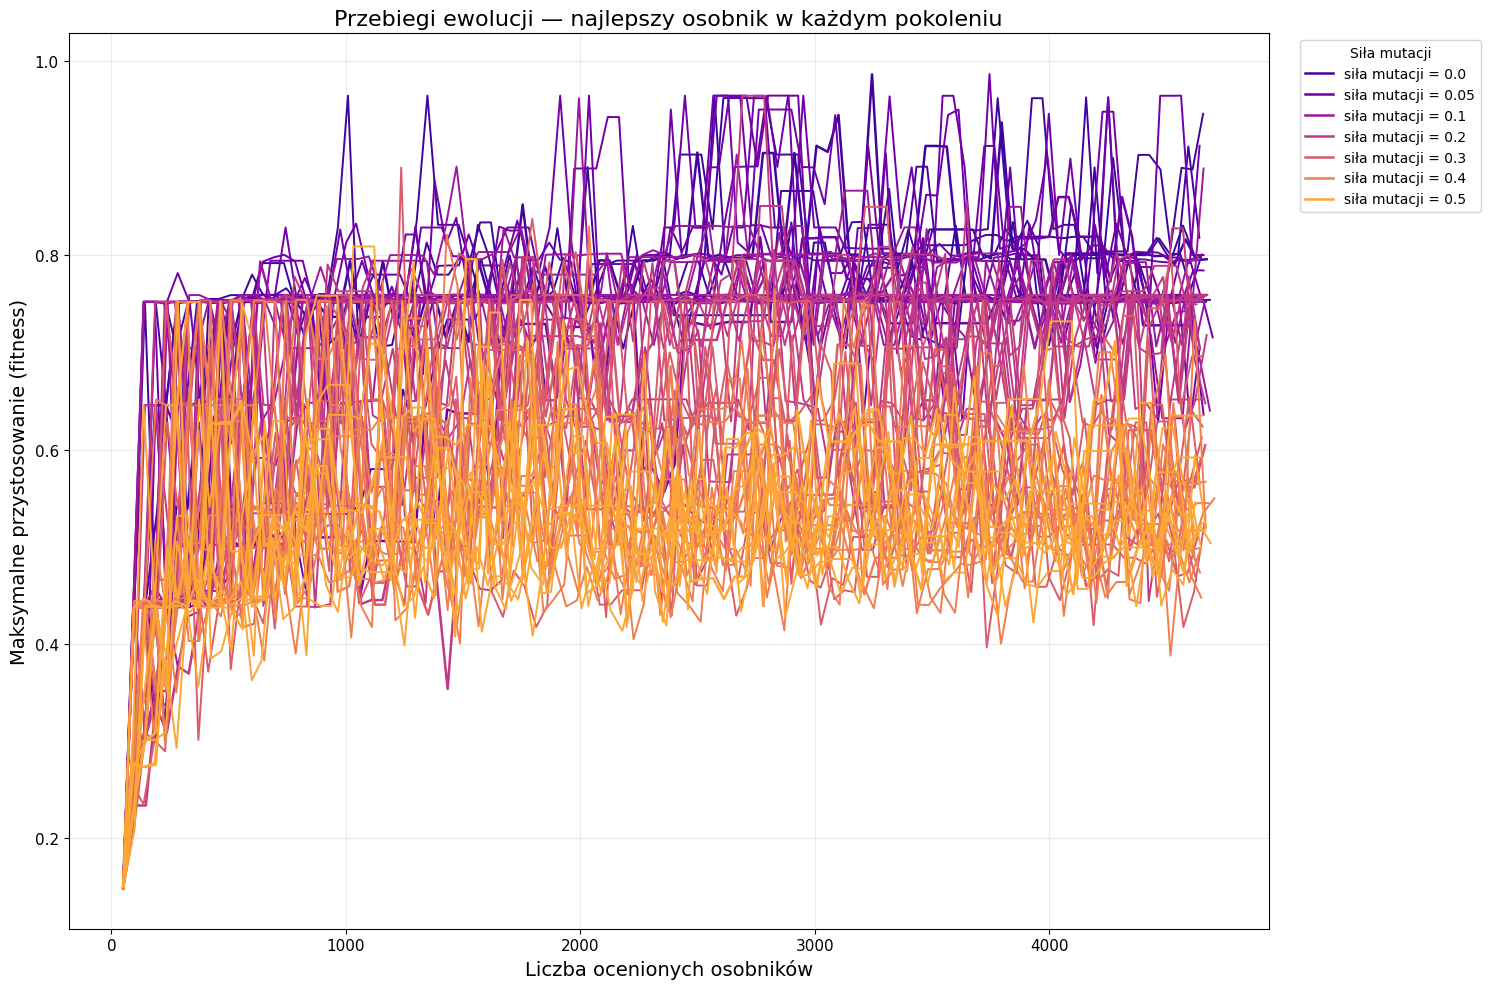

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mutation_results.csv")

# Ensure cumulative_nevals exists (compute if missing)
if "cumulative_nevals" not in df.columns:
    if "nevals" in df.columns:
        df["cumulative_nevals"] = df.groupby(["mutation_rate", "iteration"])["nevals"].cumsum()
    else:
        raise KeyError("Neither 'cumulative_nevals' nor 'nevals' column found in mutation_results.csv")

# Prepare plotting
plt.figure(figsize=(15, 10), dpi=100)
mutation_rates = sorted(df["mutation_rate"].unique())

cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.8, len(mutation_rates)))

# For consistent ordering of iterations
iterations_sorted = sorted(df["iteration"].unique())

for mutation_rate, color in zip(mutation_rates, colors):
    iters = sorted(df[df["mutation_rate"] == mutation_rate]["iteration"].unique())
    for idx, iteration in enumerate(iters):
        df_temp = df[(df["mutation_rate"] == mutation_rate) & (df["iteration"] == iteration)].sort_values("cumulative_nevals")
        if df_temp.empty:
            continue
        # label only the first line per mutation_rate for the legend
        if idx == 0:
            plt.plot(df_temp["cumulative_nevals"], df_temp["max"],
                     label=f"siła mutacji = {mutation_rate}", color=color, linewidth=1.8, alpha=1.0)
        else:
            plt.plot(df_temp["cumulative_nevals"], df_temp["max"],
                     color=color, linewidth=1.4, alpha=1.0)

# Styling
plt.title("Przebiegi ewolucji — najlepszy osobnik w każdym pokoleniu", fontsize=16)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Siła mutacji", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()

2. Zagregowana wersja powyższego wykresu, gdzie z powyższych linii o danym kolorze liczymy średnią i odchylenie standardowe. Odchylenie (być może dla czytelności podzielone przez jakąś stałą, żeby obszary na siebie nie nachodziły) pokazujemy półprzeźroczyście, na przykład tak:

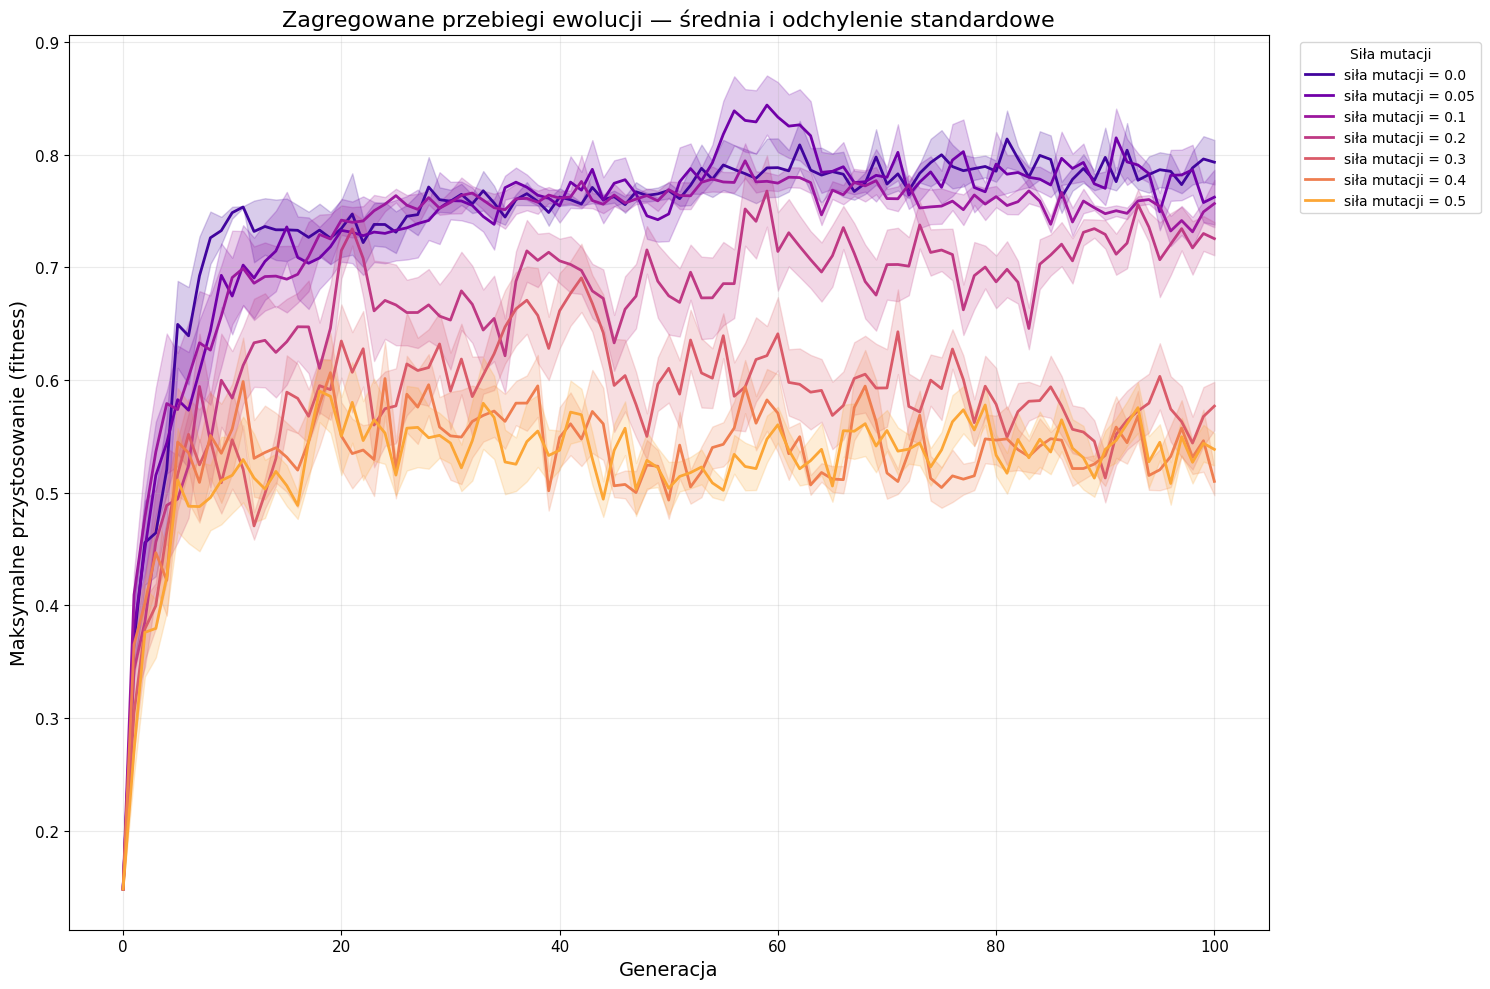

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mutation_results.csv")

# Aggregate: mean and std of 'max' for each generation and mutation_rate
df_agg = df.groupby(["gen", "mutation_rate"])["max"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(15, 10), dpi=100)
mutation_rates = sorted(df_agg["mutation_rate"].unique())

# Use the same colormap as before for consistency
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.8, len(mutation_rates)))

SCALING_FACTOR = 3

for mutation_rate, color in zip(mutation_rates, colors):
    df_temp = df_agg[df_agg["mutation_rate"] == mutation_rate]

    # Plot mean line
    plt.plot(df_temp["gen"], df_temp["mean"],
             label=f"siła mutacji = {mutation_rate}", color=color, linewidth=2)

    # Plot std as shaded area (scaled down for readability)
    plt.fill_between(df_temp["gen"],
                     df_temp["mean"] - df_temp["std"] / SCALING_FACTOR,
                     df_temp["mean"] + df_temp["std"] / SCALING_FACTOR,
                     color=color, alpha=0.2)

# Styling
plt.title("Zagregowane przebiegi ewolucji — średnia i odchylenie standardowe", fontsize=16)
plt.xlabel("Generacja", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Siła mutacji", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_zagregowane.png", dpi=200)
plt.show()


3. Najbardziej zagregowana wersja, czyli wykresy pudełkowe porównujące dla różnych parametryzacji jakość (tylko osobników z Hall of Fame, po jednym na każdy przebieg ewolucji) i czas działania (jedna wartość na każdy przebieg ewolucji), na przykład:

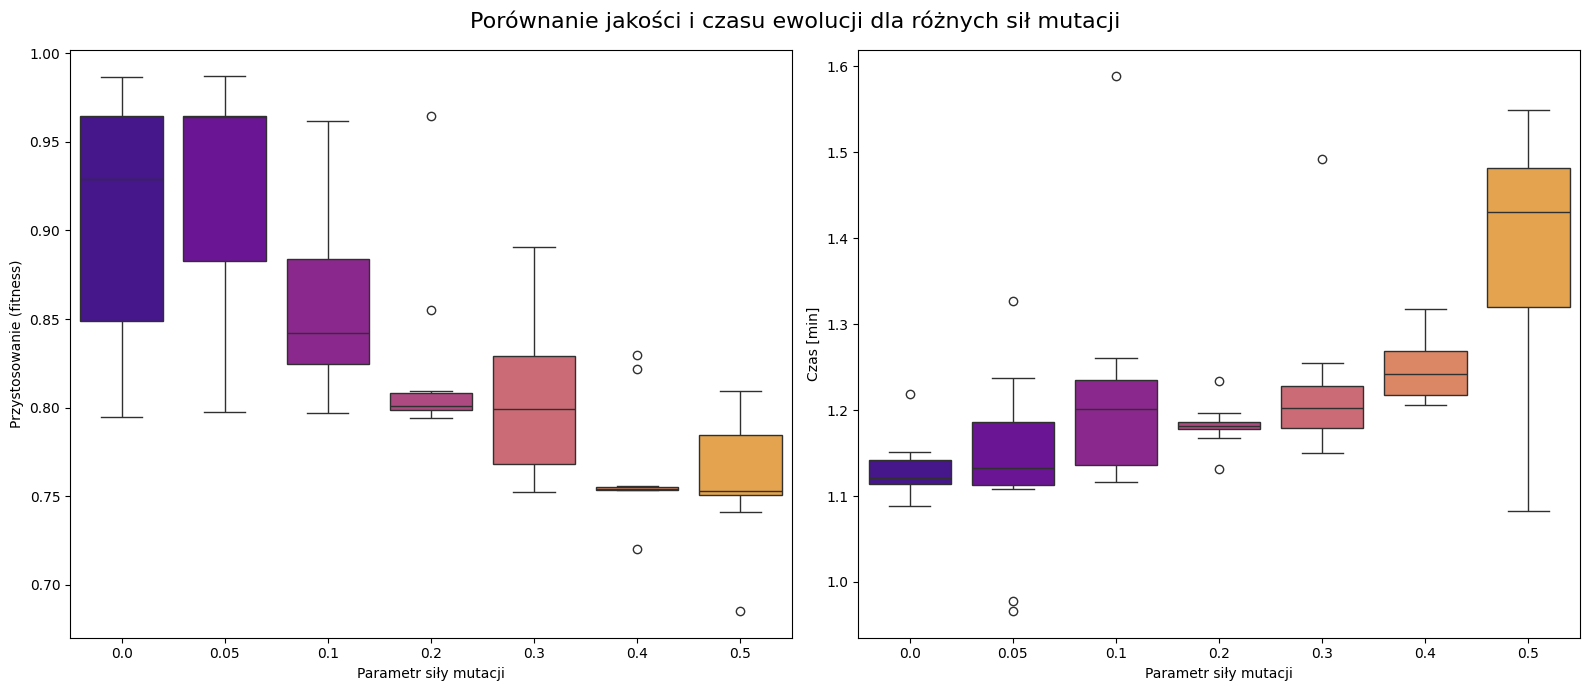

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load results
df = pd.read_csv("mutation_results.csv")

# Hall of Fame: best individual from each run
df_3 = df.groupby(["mutation_rate", "iteration"], as_index=False)["max"].max()
df_3 = df_3[["mutation_rate", "max"]]

# Load times (one value per run)
df_times = pd.read_csv("mutation_times.csv", index_col=False)
df_times["elapsed_time"] /= 60  # convert to minutes

# Convert mutation_rate to string for consistent mapping in boxplot
df_3["mutation_rate_str"] = df_3["mutation_rate"].astype(str)
df_times["mutation_rate_str"] = df_times["mutation_rate"].astype(str)

# Build a consistent color palette (same as in other plots)
mutation_rates_sorted = sorted(df["mutation_rate"].unique())
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.8, len(mutation_rates_sorted)))
palette = {str(rate): color for rate, color in zip(mutation_rates_sorted, colors)}

# Create side-by-side boxplots (Seaborn 0.14+ compatible)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

sns.boxplot(ax=axes[0], x="mutation_rate_str", y="max", data=df_3,
            hue="mutation_rate_str", palette=palette, dodge=False, legend=False)
sns.boxplot(ax=axes[1], x="mutation_rate_str", y="elapsed_time", data=df_times,
            hue="mutation_rate_str", palette=palette, dodge=False, legend=False)

# Labels
axes[0].set_xlabel("Parametr siły mutacji")
axes[0].set_ylabel("Przystosowanie (fitness)")

axes[1].set_xlabel("Parametr siły mutacji")
axes[1].set_ylabel("Czas [min]")

plt.suptitle("Porównanie jakości i czasu ewolucji dla różnych sił mutacji", fontsize=16)
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_boxploty.png", dpi=200)
plt.show()


Możesz dowolnie modyfikować źródło `FramsticksEvolution.py` tak, żeby było Ci wygodnie przekazywać informacje w obie strony, zapisywać logi oraz wyniki do plików itd. – ono służy jako przykład i punkt startowy. Jeśli chcesz mieć dostęp do parametru siły mutacji bezpośrednio ze źródła w pythonie, po wykonaniu import frams ten parametr nazywa się `frams.GenMan.f9_mu`t (to jest obiekt, jego metoda `_value()` przekonwertuje go do float).

Pora na przeprowadzenie docelowych eksperymentów i przetestowanie, czy Twoje pierwotne przewidywania o wpływie siły mutacji na przebieg ewolucji były słuszne. Obliczenia są jednowątkowe, więc jeśli chcesz wykorzystać więcej rdzeni, możesz uruchomić poszczególne procesy ewolucyjne równolegle – na przykład korzystając z parallel.

**Zbieżność**

Wcześniej – do testowania – ustawialiśmy parametry -popsize i -generations na małe wartości. Teraz ustaw -popsize na co najmniej 50, a -generations oraz -tournament na tyle, żeby zapewnić zbieżność lub nikłą szansę poprawy (z braku bardziej zaawansowanych wykresów, kieruj się tu pierwszym omówionym na początku tego pytania rodzajem wykresu).

Opcjonalnie: możesz zmodyfikować DEAP'a tak, żeby podawać "okres stagnacji" i ewolucja sama będzie się zatrzymywała, jeśli przez zadaną liczbę pokoleń (np. 50) nie nastąpi polepszenie osobnika w Hall of Fame. Taki mechanizm przyda się też przy kolejnych laboratoriach, bo uwalnia nas od ustalania a priori stałej liczby pokoleń.

To ważne, żeby nie kończyć ewolucji kiedy zachodzą poprawy rozwiązania, bo wtedy moglibyśmy wyciągnąć fałszywe wnioski. Dlatego dobierz poprawnie moment zakończenia.

**Odpowiedź**

W odpowiedzi podaj użyte wartości parametrów, załącz trzy rodzaje uzyskanych wykresów (nazywaj pliki zgodnie z ich zawartością), zinterpretuj je i napisz, czy Twoje pierwotne przypuszczenia okazały się słuszne. Co dokładnie spowodowało, że ewolucja dla pewnych wartości siły mutacji dała gorsze wyniki? Czego nas to uczy o pożądanym sposobie tworzenia "rozwiązania sąsiedniego" z "rozwiązania bieżącego" w optymalizacji? Czy te wartości siły mutacji, które przegrały w obecnej konkurencji, mają jednak jakieś zalety i czy możesz wyobrazić sobie sytuacje, w których właśnie te wartości będą najkorzystniejsze?

Na podstawie naszych wcześniejszych dyskusji oraz doświadczeń zgodziliśmy się, że zwiększanie rozmiaru sąsiedztwa powinno przynosić lepsze wyniki w optymalizacji lokalnej, ponieważ zmniejsza to liczbę lokalnych optimów. Ponieważ mutanci mogą być uznani za odpowiednik sąsiadów, a mutacja eksploruje sąsiedztwo, czy uzyskane przez Ciebie wyniki negują i unieważniają nasze wcześniejsze wnioski i oczekiwania? (ponieważ wyższa intensywność mutacji powoduje więcej zmian w rozwiązaniu, więc odpowiada większemu sąsiedztwu, prawda?) Wyjaśniając tę obserwowaną sprzeczność i porównując rozmiar sąsiedztwa w optymalizacji lokalnej z intensywnością mutacji w tym eksperymencie, pomocna może okazać się metafora koła (wypełniony obszar) oraz okręgu (sam obwód).

Ustawione parametry: 
- popsize 50
- generations 100

Watrtości odchyleń standardowych zostały podzielone przez 3 w celu zwiększenia przejrzystości wykresów.

Wyniki obserwacji po eksperymencie pokazują, że fitness najlepszego osobnika (Hall of Fame) osiąga najwyższe wartości dla najmniejszych sił mutacji (0–5%). Dla wyższych wartości siły mutacji (20–50%) fitness końcowy jest wyraźnie niższy, a ewolucja po początkowych wzrostach oscyluje wokół wartości dalekich od optimum lokalnego. Czas działania algorytmu rośnie wraz ze wzrostem siły mutacji, co jest logiczne, ponieważ więcej operacji mutacyjnych generuje więcej obliczeń.

Duża siła mutacji powoduje, że kolejne rozwiązania są zbyt odległe od obecnego optimum, a proces selekcji nie jest w stanie efektywnie utrzymać i poprawiać korzystnych cech, przez co ewolucja przypomina raczej losowe próby niż stopniowe ulepszanie. Rozwiązanie sąsiednie powinno być tworzone poprzez mutację niewielkiej liczby genów rozwiązania bieżącego, aby zachować pożądane cechy i jednocześnie wprowadzić możliwość poprawy.

Choć w obecnym eksperymencie większe wartości mutacji były niekorzystne, mogą być przydatne w początkowych fazach ewolucji, pomagając w szerokiej eksploracji przestrzeni rozwiązań i generowaniu startowych populacji, a w kolejnych generacjach siłę mutacji można stopniowo zmniejszać, aby umożliwić zbieżność do lokalnego optimum.

W optymalizacji lokalnej większe sąsiedztwo zmniejsza ryzyko utknięcia w lokalnym minimum; w naszym eksperymencie wysoka mutacja odpowiada dużemu „sąsiedztwu”, ale analogia nie jest idealna – zbyt duża mutacja może powodować skakanie poza korzystny obszar, zamiast eksploracji w jego wnętrzu.

Wpływ siły mutacji zależy od problemu – w niektórych przypadkach nawet niewielka mutacja może dramatycznie obniżyć fitness, np. destabilizacja konstrukcji, podczas gdy w innych jej wpływ będzie subtelny, np. masa konstrukcji.